# Projet : Développement d’un prototype d’imageur hyperspectral pour le banc THD2

Le code de ce notebook est divisé en trois parties :
- Partie 1 : Prétraitement de l'image se basant sur les images de spectres à bande étroite et comprend des filtres, des masques et une labellisation de celle ci, 
- Partie 2 : L'analyse des PSF et des spaxels de l'image par le calcul des tailles de PSF ainsi que des relations de dispersion des spaxels.
- Partie 3 : la construction du cube, qui permet, à partir d'une image, d'extraire les intensités à différentes longueurs d'ondes, de construire une grille régulière et de placer les spectres sur celle-ci afin de construire le cube I(x,y,λ)

Le code n'est prévu pour fonctionner que sur une zone centrale circulaire réduite de l'image complète. Cette zone est choisie pour la qualité de ces spectres : bien séparés, complets, sans aberrations qui est nommé zone 1 dans le code.

### Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from PIL import Image
from astropy.io import fits
from skimage.filters import threshold_local
from skimage.measure import label as etiqueter_connexe
from skimage.measure import regionprops
from sklearn.decomposition import PCA
from ipywidgets import interact, IntSlider
import plotly.graph_objects as go

# Partie 1 : Prétraitement de l'image

### 1) Paramètres

In [2]:
# Répertoire contenant les images .bmp
repertoire_images = "Images_Brutes"

# Zone 1 (disque) choisie par l’utilisateur:
# - pour sommer_zone_disque : centre en (y, x)
centre_disque_yx = (600, 700)
# - pour filtrer_spaxels_entiers : centre en (x, y)
centre_disque_xy = (700, 600)
rayon_zone1 = 250

# Seuillage local
block_size = 25
offset_pct = 132.0
facteur_contour = 76.0

# Filtrage des régions (spaxels) par aire (en pixels)
min_pixels = 100
max_pixels = 160

# Filtrage “spaxels entiers”
marge_bord = 2
valeur_fond = 0.0

# PSF (seuil relatif au max de chaque image à une longueur d’onde donnée)
seuil_intensite_psf = 0.1


### 2) Chargement des images (.bmp) et association aux longueurs d’onde

In [3]:
def charger_images_bmp(repertoire: str):
    """
    Charge toutes les images `.bmp` du répertoire et sépare :
    - images "scène" (ex: "670_2.bmp")  -> {lambda: [images...]}
    - images "dark"  (ex: "660_dark_1.bmp") -> {lambda: [dark...]}
    """

    # vérification du répertoire
    if not os.path.isdir(repertoire):
        raise FileNotFoundError(
            f"Répertoire introuvable : {repertoire}"
        )

    # dictionnaires de sortie
    images_par_lambda = {}
    darks_par_lambda = {}

    # parcours du répertoire
    for nom_fichier in os.listdir(repertoire):

        # ne traiter que les fichiers .bmp
        if not nom_fichier.lower().endswith(".bmp"):
            continue

        # chargement de l’image
        chemin = os.path.join(repertoire, nom_fichier)
        image = np.array(Image.open(chemin)).astype(float)

        nom = nom_fichier.lower()

        # séparation dark / scène
        if "dark" in nom:
            # ex: "660_dark_1.bmp" -> parts[0] = "660"
            parts = nom_fichier.split("_")
            lambda_nm = int(parts[0])
            darks_par_lambda.setdefault(lambda_nm, []).append(image)
        else:
            # ex: "670_2.bmp" -> "670"
            lambda_nm = int(nom_fichier.split("_")[0])
            images_par_lambda.setdefault(lambda_nm, []).append(image)

    # tri (pour la suite)
    images_par_lambda = dict(sorted(images_par_lambda.items()))
    darks_par_lambda = dict(sorted(darks_par_lambda.items()))
    return images_par_lambda, darks_par_lambda

# Chargement des images
images_brutes_par_lambda, darks_par_lambda = charger_images_bmp(repertoire_images)
liste_lambda = sorted(images_brutes_par_lambda.keys())

print("Longueurs d’onde détectées :", liste_lambda)
print("Longueurs d’onde dark détectées :", sorted(darks_par_lambda.keys()))

Longueurs d’onde détectées : [647, 660, 670, 680, 690, 700, 710]
Longueurs d’onde dark détectées : [647, 660, 670, 680, 690, 700, 710]


### 3) Moyennage (par longueur d’onde), correction dark, puis normalisation par la somme

In [4]:
def moyenne_images_par_lambda(images_dict):
    """Calcule la moyenne des images (liste) pour chaque longueur d’onde."""

    # dictionnaire de sortie
    moyennes = {}

    # calcul des moyennes
    for lambda_nm, liste_images in images_dict.items():
        pile = np.stack(liste_images, axis=0)
        moyennes[lambda_nm] = np.mean(pile, axis=0)
    
    return moyennes

def normaliser_par_somme(images_par_lambda, darks_par_lambda):
    """
    Normalisation par somme des images, après soustraction du dark moyen :
    - moyenne image et moyenne dark à chaque λ
    - image_corr = max(image - dark, 0)
    - normalisation : image_corr / somme(image_corr)
    """
    
    # moyennes des images et darks
    moyennes_images = moyenne_images_par_lambda(images_par_lambda)

    # dark moyen : si dark manquant pour une λ, on met un dark nul 
    moyennes_darks = moyenne_images_par_lambda(darks_par_lambda) if len(darks_par_lambda) > 0 else {}

    # dictionnaire de sortie
    images_normalisees = {}

    # traitement par λ
    for lambda_nm, img_moy in moyennes_images.items():

        # dark moyen (ou nul si absent)
        dark_moy = moyennes_darks.get(lambda_nm, np.zeros_like(img_moy))

        # soustraction du dark et clipping
        img_corr = img_moy - dark_moy
        img_corr = np.clip(img_corr, 0.0, None)  # valeurs négatives -> 0

        # somme
        S = float(np.sum(img_corr))
        if S <= 0:
            # on ignore la longueur d’onde si image nulle
            print(f"Image nulle après dark pour {lambda_nm} nm (somme=0). Ignorée.")
            continue

        # normalisation
        images_normalisees[lambda_nm] = img_corr / S

    # tri final
    images_normalisees = dict(sorted(images_normalisees.items()))

    return images_normalisees

# Normalisation par somme après soustraction du dark
images_norm = normaliser_par_somme(images_brutes_par_lambda, darks_par_lambda)
liste_lambda = sorted(images_norm.keys())  # on met à jour (certaines λ peuvent avoir été ignorées)

# pile d'images normalisées (ordre = liste_lambda)
liste_image_BE = np.stack([images_norm[lam] for lam in liste_lambda], axis=0)




### 4) Somme dans un disque (zone 1), puis normalisation

In [5]:
def sommer_zone_disque(images_dict, rayon, centre_yx):
    """
    Somme des images sur toutes les longueurs d’onde dans un disque (zone 1),
    en mettant 0 en dehors.
    """

    # coordonnées du centre
    cy, cx = centre_yx

    # on prend une image pour dimensionner
    une_image = next(iter(images_dict.values()))
    H, W = une_image.shape

    # coordonnées du masque
    Y, X = np.ogrid[:H, :W]

    # masque disque
    masque = (X - cx) ** 2 + (Y - cy) ** 2 <= rayon ** 2

    # somme des images dans le disque
    image_somme = np.zeros((H, W), dtype=float)
    for img in images_dict.values():
        image_somme[masque] += img[masque]

    return image_somme

# Somme dans le disque (zone 1)
new_image_specter = sommer_zone_disque(images_norm, rayon=rayon_zone1, centre_yx=centre_disque_yx)
max_somme = float(new_image_specter.max())

# Vérification de la somme
if max_somme <= 0:
    raise RuntimeError("La somme des images normalisées est nulle (max=0).")

# normalisation finale
new_image_specter = new_image_specter / max_somme

### 5) Seuillage local + carte de labels + filtrage par aire

In [6]:
def seuillage_local(image, block_size, offset_pct, facteur_contour):
    """
    Seuillage local adaptatif :
    - seuil local = threshold_local(image, block_size)
    - seuil "coeur" = seuil_local * (offset_pct/100)
    - contour : pixels entre (seuil_coeur_local * facteur_contour/100) et seuil_coeur_local
    - masque final = coeur OU contour
    """

    # calcul du seuil local et du seuil coeur
    seuil_local_img = threshold_local(image, block_size)
    seuil_coeur_local = seuil_local_img * (offset_pct / 100.0)

    # création des masques
    masque_coeur = image > seuil_coeur_local
    masque_contour = (image > seuil_coeur_local * (facteur_contour / 100.0)) & (image <= seuil_coeur_local)
    masque_final = np.logical_or(masque_coeur, masque_contour)

    return masque_coeur, masque_contour, masque_final


def masque_vers_labels(masque, min_pixels, max_pixels):
    """
    Labellisation des régions connexes + filtrage par aire dans [min_pixels, max_pixels].
    Renvoie :
    - labels_filtrés (labels renumérotés de 1..N)
    - liste de propriétés (centroïde, aire)
    """

    # labellisation initiale
    labels_init = etiqueter_connexe(masque)

    # initialisation des sorties
    labels_filtrés = np.zeros_like(labels_init, dtype=int)
    regions_conservees = []

    # filtrage par aire et renumérotation
    compteur = 1
    for region in regionprops(labels_init):
        if min_pixels <= region.area <= max_pixels:
            coords = np.array(region.coords, dtype=int)
            labels_filtrés[coords[:, 0], coords[:, 1]] = compteur
            regions_conservees.append({"label": compteur, "centroid": region.centroid, "area": region.area})
            compteur += 1

    return labels_filtrés, regions_conservees

# Création des masques par seuillage local
image_seuil_coeur, image_seuil_contour, image_seuil_final = seuillage_local(
    new_image_specter,
    block_size=block_size,
    offset_pct=offset_pct,
    facteur_contour=facteur_contour,
)

# Labellisation et filtrage des régions
labels_filtre, regions_conservees = masque_vers_labels(
    image_seuil_final,
    min_pixels=min_pixels,
    max_pixels=max_pixels,
)

### 6) Filtrer les spaxels “entiers” à l’intérieur du disque (rayon - marge)

In [7]:
def filtrer_spaxels_entiers(image, labels_spaxels, centre_xy, rayon, marge, valeur_fond):
    """
    Conserve uniquement les spaxels entièrement inclus dans un disque de rayon (rayon - marge).
    Convention : centre_xy = (x_centre, y_centre).

    Renvoie :
    - image_filtrée : intensités avec pixels supprimés -> valeur_fond
    - labels_filtrés : labels conservés (avec labels initiaux)
    - labels_relabelisés : labels re-numérotés consécutifs (1..N)
    """

    # coordonnées du centre
    x0, y0 = centre_xy
    # masque du disque réduit
    H, W = image.shape
    Y, X = np.ogrid[:H, :W]
    masque_disque = (X - x0) ** 2 + (Y - y0) ** 2 <= (rayon - marge) ** 2

    # initialisation des sorties
    image_filtrée = np.full_like(image, valeur_fond, dtype=float)
    labels_filtrés = np.zeros_like(labels_spaxels, dtype=int)

    # parcours des labels
    for lbl in np.unique(labels_spaxels):
        if lbl == 0:
            continue
        masque_spaxel = labels_spaxels == lbl

        # spaxel conservé si TOUS ses pixels sont dans le disque réduit
        if np.all(masque_disque[masque_spaxel]):
            labels_filtrés[masque_spaxel] = lbl
            image_filtrée[masque_spaxel] = image[masque_spaxel]

    # relabelisation (labels 1..N)
    labels_relabelisés = etiqueter_connexe(labels_filtrés > 0)

    return image_filtrée, labels_filtrés, labels_relabelisés

# Filtrage des spaxels entiers
final_image_zone1, final_label_zone1, final_label_relabelisé = filtrer_spaxels_entiers(
    image=new_image_specter,
    labels_spaxels=labels_filtre,
    centre_xy=centre_disque_xy,
    rayon=rayon_zone1,
    marge=marge_bord,
    valeur_fond=valeur_fond,
)

### 7) Visualisation de l'image finale après traitements et des spaxels labellisés

In [ ]:
# --- 1) Image finale après tous les traitements (niveau de gris) ---
fig1 = px.imshow(
    final_image_zone1,
    color_continuous_scale="gray",
    origin="upper",
    title="Image finale après traitements (zone 1)",
)

fig1.update_layout(
    width=600,
    height=600,
    coloraxis_colorbar=dict(title="Intensité normalisée"),
    margin=dict(l=10, r=10, t=60, b=10),
)

# masquer axes
fig1.update_xaxes(visible=False)
fig1.update_yaxes(visible=False)

fig1.show()


# --- 2) Carte des labels construite à partir de l'image finale ---
labels = np.asarray(final_label_relabelisé)

# Masquer le fond
labels_show = labels.astype(float)
labels_show[labels_show == 0] = np.nan

# Affichage avec une colormap
fig = px.imshow(
    labels_show,
    color_continuous_scale="gray",
    origin="upper",
    title="Carte des labels finale (spaxels conservés)",
    zmin=np.nanmin(labels_show),
    zmax=np.nanmax(labels_show),
)

# Fond noir + axes cachés
fig.update_layout(
    width=600, height=600,
    plot_bgcolor="blue",
    coloraxis_colorbar=dict(title="Label spaxel"),
    margin=dict(l=10, r=10, t=60, b=10),
)

fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)

fig.show()


# Partie 2 : Analyse des PSF et des spaxels

### 8) Relations de dispersion : $\lambda = a\,s + b$ pour chaque spaxel

In [9]:
# --- Paramètres de la partie dispersion ---
# Seuil relatif (par spaxel et par longueur d’onde) : on ne garde que les pixels dont l’intensité est > seuil_rel_spot * max(intensité dans le spaxel)
seuil_rel_spot = 0.20

def calculer_relations_dispersion(
    carte_labels: np.ndarray,
    images_norm: dict,
    liste_lambda: list,
    seuil_relatif: float = 0.20,
):
    """
    Calcule, pour chaque spaxel k, la loi de dispersion linéaire :
        lambda = a_k * s + b_k

    Entrées
    -------
    carte_labels : (H, W) int
        Carte des labels finale, labels 1..N.
    images_norm : dict[int -> (H, W) float]
        Dictionnaire {lambda_nm: image_normalisée}, obtenu plus haut dans le notebook.
    liste_lambda : list[int]
        Liste triée des longueurs d'onde disponibles.
    seuil_relatif : float
        Seuil relatif appliqué dans chaque spaxel : pixels retenus si I > seuil_relatif * Imax_spaxel.

    Sorties
    -------
    a_dispersion : np.ndarray shape (N,)
    b_dispersion : np.ndarray shape (N,)
        Coefficients de dispersion par spaxel (indice k-1 -> spaxel k).
    vecteurs_u : np.ndarray shape (N, 2)
        Vecteur unitaire u = (ux, uy) qui donne la direction du micro-spectre pour chaque spaxel.
    s_proj_par_spaxel : dict[int -> list[float]]
        Pour chaque spaxel k, la liste des s_max(λ) dans l’ordre de `liste_lambda`.
    """

    # nombre de spaxels
    nb_spaxels = int(carte_labels.max())

    # initialisation des sorties
    a_dispersion = np.full(nb_spaxels, np.nan, dtype=float)
    b_dispersion = np.full(nb_spaxels, np.nan, dtype=float)
    vecteurs_u = np.full((nb_spaxels, 2), np.nan, dtype=float)

    s_proj_par_spaxel = {}

    # Prépare la liste d'images dans le même ordre que liste_lambda
    images_etalonnage = [images_norm[lam] for lam in liste_lambda]

    # Parcours des spaxels
    for k in range(1, nb_spaxels + 1):

        masque = (carte_labels == k)

        # Vérification spaxel non vide
        if not np.any(masque):
            s_proj_par_spaxel[k] = [np.nan] * len(liste_lambda)
            continue

        # Coordonnées des pixels du spaxel
        y_pix, x_pix = np.where(masque)
        x_c = float(np.mean(x_pix))
        y_c = float(np.mean(y_pix))

        # Estimation direction micro-spectre : fit y = m x + c
        m, c = np.polyfit(x_pix, y_pix, deg=1)

        # Vecteur direction non normalisé puis normalisation -> u
        v = np.array([1.0, m], dtype=float)
        norme = np.linalg.norm(v)
        if norme == 0:
            s_proj_par_spaxel[k] = [np.nan] * len(liste_lambda)
            continue
        u = v / norme
        vecteurs_u[k - 1] = u

        # Projection s de chaque pixel du spaxel sur u
        # Convention : s=0 au barycentre géométrique du spaxel (x_c, y_c)
        X_centre = np.column_stack((x_pix - x_c, y_pix - y_c))
        s_proj = X_centre @ u  # shape = (nb_pixels_spaxel,)

        # Pour chaque λ : calcule s_max(λ) comme barycentre pondéré sur pixels “au-dessus” du seuil relatif
        s_vals = []
        lam_vals = []
        # parcours des images à chaque λ
        for image_lambda, lam in zip(images_etalonnage, liste_lambda):
            intensites = image_lambda[masque]  # intensités sur les pixels du spaxel

            # gestion cas intensités nulles
            if intensites.size == 0:
                s_vals.append(np.nan)
                lam_vals.append(lam)
                continue
            
            # calcul du max
            Imax = float(np.max(intensites))
            if Imax <= 0:
                s_vals.append(np.nan)
                lam_vals.append(lam)
                continue
            
            # application du seuil relatif
            seuil_abs = seuil_relatif * Imax
            ok = intensites > seuil_abs

            # calcul de s_max(λ)
            if np.any(ok):
                denom = float(np.sum(intensites[ok]))
                if denom > 0:
                    s_max = float(np.sum(s_proj[ok] * intensites[ok]) / denom)
                else:
                    s_max = np.nan
            else:
                s_max = np.nan

            # stockage
            s_vals.append(s_max)
            lam_vals.append(lam)

        # stockage des s_proj pour ce spaxel
        s_proj_par_spaxel[k] = s_vals

        # Ajustement λ = a*s + b en ignorant les NaN
        s_arr = np.array(s_vals, dtype=float)
        lam_arr = np.array(lam_vals, dtype=float)
        okfit = np.isfinite(s_arr) & np.isfinite(lam_arr)
        
        if np.sum(okfit) >= 2:
            a, b = np.polyfit(s_arr[okfit], lam_arr[okfit], deg=1)
            a_dispersion[k - 1] = float(a)
            b_dispersion[k - 1] = float(b)

    return a_dispersion, b_dispersion, vecteurs_u, s_proj_par_spaxel

# Calcul effectif des relations de dispersion
a_dispersion, b_dispersion, vecteurs_u, s_proj_par_spaxel = calculer_relations_dispersion(
    carte_labels=final_label_relabelisé,
    images_norm=images_norm,
    liste_lambda=liste_lambda,
    seuil_relatif=seuil_rel_spot,
)

print(f"Dispersion calculée : {np.sum(np.isfinite(a_dispersion))} spaxels / {len(a_dispersion)}.")


Dispersion calculée : 483 spaxels / 483.


**Visualisation des droites de dispersion et des R² associés**

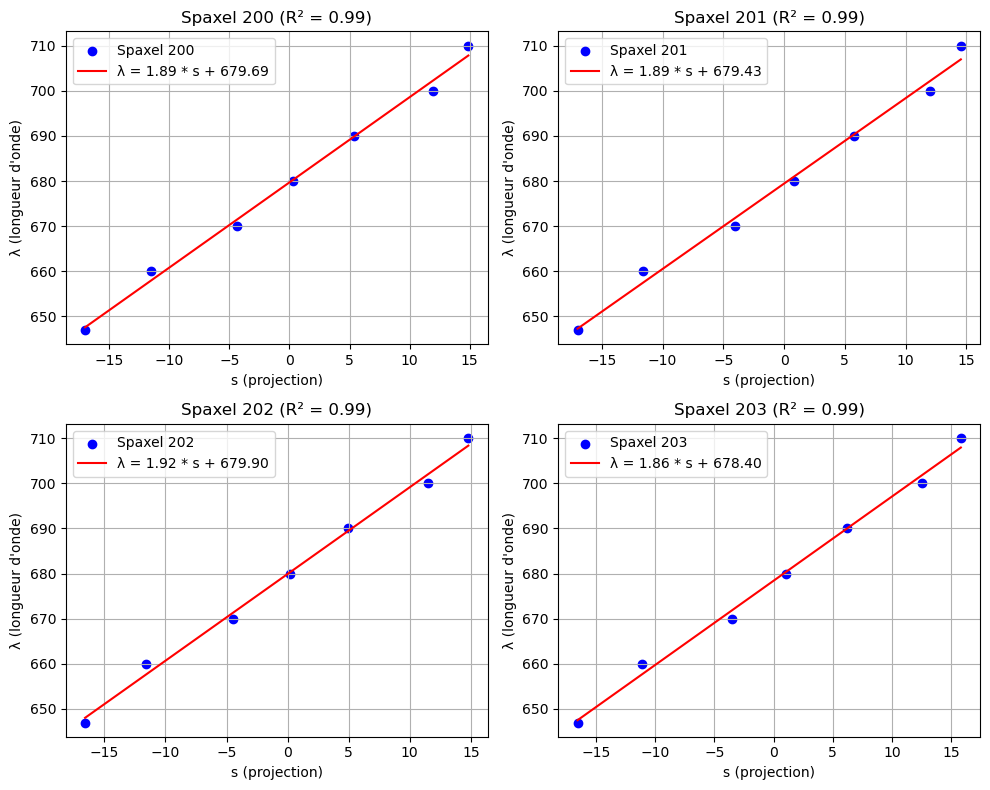

In [10]:
def plot_dispersion_spaxels(spaxels, s_proj_par_spaxel, liste_lambda, a_dispersion, b_dispersion):
    """
    Affiche les points et les droites de dispersion pour les spaxels donnés, avec le R^2.

    Parameters:
        spaxels (list): Liste des IDs des spaxels à afficher.
        s_proj_par_spaxel (dict): Projections s(λ) pour chaque spaxel.
        liste_lambda (list): Longueurs d'onde correspondantes.
        a_dispersion (np.ndarray): Coefficients a de dispersion.
        b_dispersion (np.ndarray): Coefficients b de dispersion.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for i, spaxel_id in enumerate(spaxels):
        if i >= len(axes):
            break

        ax = axes[i]
        s_proj = s_proj_par_spaxel.get(spaxel_id, [])
        a = a_dispersion[spaxel_id - 1]
        b = b_dispersion[spaxel_id - 1]

        if not s_proj or not np.isfinite(a) or not np.isfinite(b):
            ax.set_title(f"Spaxel {spaxel_id} (données manquantes)")
            continue

        # Points
        ax.scatter(s_proj, liste_lambda, label=f"Spaxel {spaxel_id}", color="blue")

        # Droite de dispersion
        s_range = np.linspace(min(s_proj), max(s_proj), 100)
        lambda_fit = a * s_range + b
        ax.plot(s_range, lambda_fit, label=f"λ = {a:.2f} * s + {b:.2f}", color="red")

        # Calcul de R^2
        lambda_pred = a * np.array(s_proj) + b
        ss_res = np.sum((np.array(liste_lambda) - lambda_pred) ** 2)
        ss_tot = np.sum((np.array(liste_lambda) - np.mean(liste_lambda)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        # Configuration du graphique
        ax.set_title(f"Spaxel {spaxel_id} (R² = {r_squared:.2f})")
        ax.set_xlabel("s (projection)")
        ax.set_ylabel("λ (longueur d'onde)")
        ax.legend()
        ax.grid()

    plt.tight_layout()
    plt.show()

# Appel de la fonction pour les spaxels 200 à 204
plot_dispersion_spaxels(
    spaxels=[200, 201, 202, 203],
    s_proj_par_spaxel=s_proj_par_spaxel,
    liste_lambda=liste_lambda,
    a_dispersion=a_dispersion,
    b_dispersion=b_dispersion,
)

### 9) Estimation PSF par spaxel et longueur d’onde (PCA)

In [11]:
def calculer_psf_par_spaxel(pile_images_par_lambda, labels_spaxels, liste_lambda, seuil_intensite):
    """
    Estime (x0, y0, sigma1, sigma2) par PCA pour chaque spaxel et chaque λ.

    - Pour chaque λ : on sélectionne, dans le spaxel, les pixels dont I > seuil_intensite * max(I_λ)
    - x0, y0 : barycentre des pixels sélectionnés
    - sigma1, sigma2 : échelles le long des axes principaux (sqrt(var) sur chaque axe PCA)
    """

    # liste de résultats
    resultats = []
    labels_uniques = [lbl for lbl in np.unique(labels_spaxels) if lbl != 0]

    # parcours des longueurs d’onde
    for idx_lambda, lambda_nm in enumerate(liste_lambda):

        # image à la longueur d’onde courante
        image_lambda = pile_images_par_lambda[idx_lambda]
        # seuil absolu
        seuil_abs = float(seuil_intensite) * float(image_lambda.max())

        # parcours des spaxels
        for id_spaxel in labels_uniques:
            masque_spaxel = labels_spaxels == id_spaxel
            masque_sel = masque_spaxel & (image_lambda > seuil_abs)

            # coordonnées des pixels sélectionnés
            ys, xs = np.nonzero(masque_sel)
            if xs.size < 2:
                # trop peu de points -> on saute
                continue

            # calcul du barycentre
            x0 = float(xs.mean())
            y0 = float(ys.mean())

            # PCA sur les coordonnées centrées
            coords = np.column_stack([xs - x0, ys - y0])  # centrage
            pca = PCA(n_components=2)
            pca.fit(coords)

            # variances le long des axes (explained_variance_) -> sigmas
            sigmas = np.sqrt(np.maximum(pca.explained_variance_, 0.0))
            sigma1 = float(sigmas[0]) if sigmas.size > 0 else np.nan
            sigma2 = float(sigmas[1]) if sigmas.size > 1 else np.nan

            # stockage du résultat
            resultats.append(
                {
                    "longueur_d_onde": int(lambda_nm),
                    "spaxel": int(id_spaxel),
                    "x0": x0,
                    "y0": y0,
                    "sigma1": sigma1,
                    "sigma2": sigma2,
                }
            )

    return resultats


# Calcul des PSF par spaxel
dimensions_psf = calculer_psf_par_spaxel(
    pile_images_par_lambda=liste_image_BE,
    labels_spaxels=final_label_relabelisé,
    liste_lambda=liste_lambda,
    seuil_intensite=seuil_intensite_psf,
)


**Visualisation de l'ellipse représentant les PSF pour un spaxel donné sur une image donnée à chaque longueur d'onde**

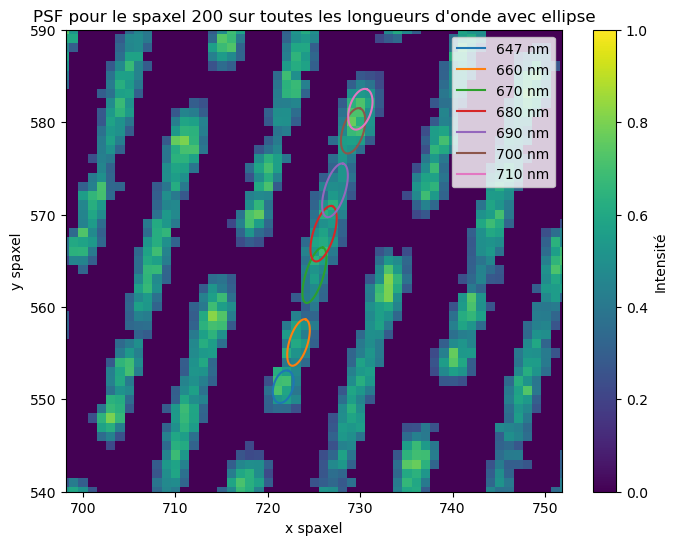

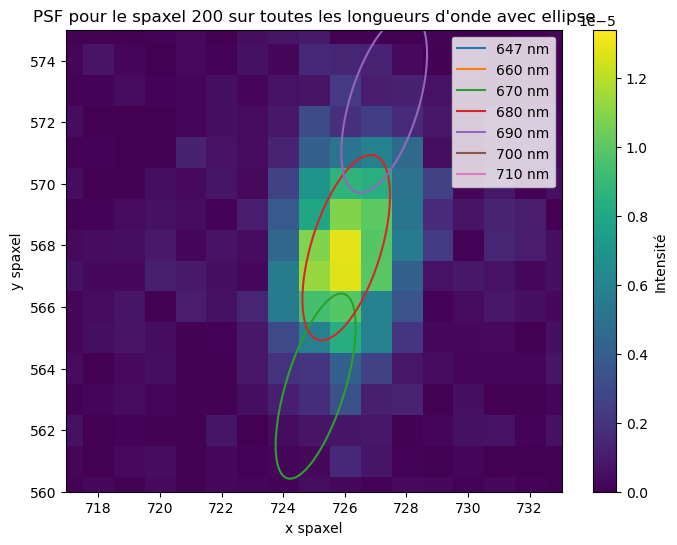

In [12]:
import matplotlib.pyplot as plt

def plot_psf_spaxel(spaxel_id, image, dimensions_psf, plot_type="rayon", alpha=1.2, xlim=(710,740), ylim=(540,590)):
    """
    Visualise la PSF pour un spaxel donné avec un cercle ou une ellipse.

    Parameters:
        spaxel_id (int): ID du spaxel à afficher.
        image (numpy.ndarray): Image de référence.
        dimensions_psf (list): Liste contenant les dimensions PSF (x0, y0, sigma1, sigma2, etc.).
        plot_type (str): Type de plot ("rayon" pour un cercle ou "ellipse" pour une ellipse).
        alpha (float): Facteur d'échelle pour les dimensions PSF.
    """
    # Récupérer l'angle du spaxel à partir du vecteur directeur
    ux, uy = vecteurs_u[spaxel_id - 1]  # spaxel_id commence à 1
    angle = np.arctan2(uy, ux)  # angle en radians

    # Créer la figure
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap="viridis", origin="upper")
    plt.colorbar(label="Intensité")

    # Boucle sur toutes les longueurs d'onde pour ce spaxel
    for dim in dimensions_psf:
        if dim["spaxel"] == spaxel_id:
            x0 = dim["x0"]
            y0 = dim["y0"]
            sigma1 = dim["sigma1"]
            sigma2 = dim["sigma2"]
            lambda_val = dim["longueur_d_onde"]

            if plot_type == "rayon":
                # Créer les points du cercle
                theta = np.linspace(0, 2 * np.pi, 100)
                x = x0 + alpha * sigma2 * np.cos(theta)
                y = y0 + alpha * sigma2 * np.sin(theta)
            elif plot_type == "ellipse":
                # Créer les points de l'ellipse
                theta = np.linspace(0, 2 * np.pi, 100)
                x = x0 + (sigma1 * np.cos(theta) * np.cos(angle)) - (sigma2 * np.sin(theta) * np.sin(angle))
                y = y0 + (sigma1 * np.cos(theta) * np.sin(angle)) + (sigma2 * np.sin(theta) * np.cos(angle))
            else:
                raise ValueError("plot_type doit être 'rayon' ou 'ellipse'.")

            # Ajouter la forme à la figure
            plt.plot(x, y, label=f"{lambda_val} nm")

    # Configurer l'affichage
    plt.title(f"PSF pour le spaxel {spaxel_id} sur toutes les longueurs d'onde avec {plot_type}")
    plt.xlabel("x spaxel")
    plt.ylabel("y spaxel")
    plt.axis("equal") 
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.legend(loc="upper right")
    plt.show()
# Exemple d'utilisation
plot_psf_spaxel(spaxel_id=200, image=final_image_zone1, dimensions_psf=dimensions_psf, plot_type="ellipse", alpha=1.2)
plot_psf_spaxel(spaxel_id=200, image=liste_image_BE[3], dimensions_psf=dimensions_psf, plot_type="ellipse", alpha=1.2, xlim=(720,730), ylim=(560,575))


# Partie 3 : Construction du cube

### 10) Axe spectral du cube (défini par l'utilisateur)

In [13]:
# Paramètres du cube : longueurs d’onde min et max et nombre de tranches/longueurs d'onde du cube
lambda_min = 650.0
lambda_max = 710.0
N_lambda_cube = 10
lambdas_cube = np.linspace(lambda_min, lambda_max, N_lambda_cube)  # axe spectral du cube

### 11) Outils : barycentres des spaxels + rayon d'intégration par spaxel

In [14]:
def calcul_coord_spaxels(label):
    """
    Calcule les coordonnées (x, y) des barycentres de chaque spaxel à partir de la carte des labels.
    Renvoie un tableau `coord_spaxels[k-1] = [x_k, y_k]`.
    """

    # nombre de spaxels
    num_spaxels = int(label.max())
    # initialisation du tableau des coordonnées
    coord_spaxels = np.full((num_spaxels, 2), np.nan, dtype=float)

    # parcours des spaxels
    for k in range(1, num_spaxels + 1):

        mask = (label == k)

        if not np.any(mask):
            continue

        # coordonnées des pixels du spaxel
        y_pix, x_pix = np.where(mask)

        # calcul du barycentre
        coord_spaxels[k - 1] = [np.mean(x_pix), np.mean(y_pix)]

    return coord_spaxels


def calculer_rayon_par_spaxel(dimensions_psf, nb_spaxels, alpha_rayon=1.2, rayon_defaut=2):
    """
    Prend toutes les largeurs de PSF (sigma) mesurées pour cahque spaxel à différentes longueurs d'onde, en tire une valeur typique (la médiane),
    et transforme ça en rayon d'intégration (en pixels) pour l'estimation de I(λ) faitre plus loin. On multiplie la médiane par 
    un facteur alpha_rayon pour obtenir le rayon final.
    
    Retourne un tableau `rayons[k-1]` en pixels.

    On utilise sigma2 si dispo, sinon sigma1.
    rayon_k = ceil(alpha_rayon * median(sigma2_k)).
    """

    # collecte des sigmas par spaxel
    sigmas = {k: [] for k in range(1, nb_spaxels + 1)}

    # parcours des entrées
    for entry in dimensions_psf:

        # récupération de l'identifiant du spaxel
        k = entry.get("spaxel", None)
        if k is None:
            continue

        # récupération de sigma
        sigma = entry.get("sigma2", entry.get("sigma1", np.nan))
        if sigma is None or (not np.isfinite(sigma)) or sigma <= 0:
            continue

        # ajout à la liste
        if 1 <= int(k) <= nb_spaxels:
            sigmas[int(k)].append(float(sigma))


    rayons = np.full(nb_spaxels, float(rayon_defaut), dtype=float)

    # calcul des rayons par spaxel
    for k in range(1, nb_spaxels + 1):
        if len(sigmas[k]) > 0:
            rayon_k = int(np.ceil(alpha_rayon * np.median(sigmas[k])))
            rayons[k - 1] = max(1, rayon_k)

    return rayons


# Barycentres des spaxels
coord_spaxels = calcul_coord_spaxels(final_label_relabelisé)
nb_spaxels = coord_spaxels.shape[0]

# Rayons d'intégration par spaxel (en pixels)
alpha_rayon = 1.2
rayons_spaxels = calculer_rayon_par_spaxel(dimensions_psf, nb_spaxels, alpha_rayon=alpha_rayon, rayon_defaut=2)

**Visualisation du disque d'intégration pour un spaxel donné sur l'image**

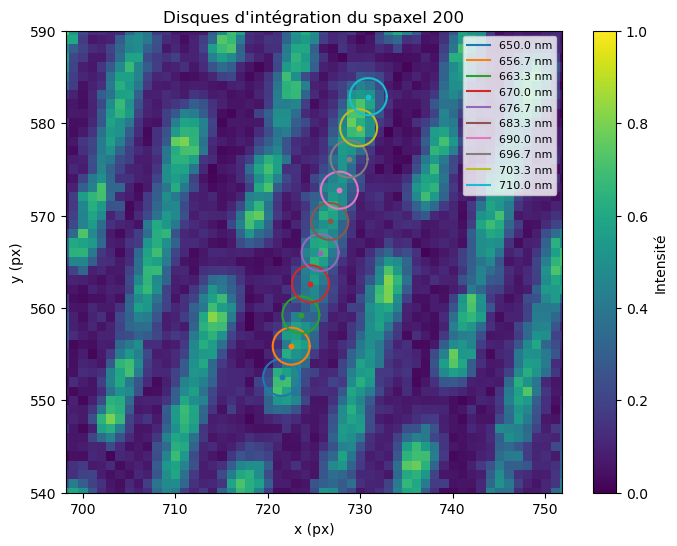

In [15]:
def plot_psf_spaxel_cube(
    spaxel_id,
    image,
    coord_spaxels,
    a_dispersion,
    b_dispersion,
    vecteurs_u,
    lambdas_cube,
    rayons_spaxels,
    alpha=1.0,
):
    """
    Affiche les disques d'intégration utilisés pour construire le cube
    pour un spaxel donné et les longueurs d'onde du cube.
    """

    idx = spaxel_id - 1

    # Vérifications
    if np.isnan(coord_spaxels[idx]).any():
        print("Spaxel invalide")
        return

    a = a_dispersion[idx]
    b = b_dispersion[idx]
    ux, uy = vecteurs_u[idx]
    x_c, y_c = coord_spaxels[idx]
    rayon = alpha * rayons_spaxels[idx]

    if not np.isfinite([a, b, ux, uy]).all() or a == 0:
        print("Dispersion invalide")
        return

    # Affichage image
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap="viridis", origin="upper")
    plt.colorbar(label="Intensité")
    
    theta = np.linspace(0, 2*np.pi, 100)

    # Tracé pour chaque λ du cube
    for lam in lambdas_cube:
        s = (lam - b) / a
        x_lam = x_c + s * ux
        y_lam = y_c + s * uy

        x = x_lam + rayon * np.cos(theta)
        y = y_lam + rayon * np.sin(theta)

        plt.plot(x, y, label=f"{lam:.1f} nm")

        # centre du disque (optionnel mais très utile)
        plt.scatter(x_lam, y_lam, s=10)

    plt.title(f"Disques d'intégration du spaxel {spaxel_id}")
    plt.xlabel("x (px)")
    plt.ylabel("y (px)")
    plt.axis("equal")
    plt.xlim(710, 740)
    plt.ylim(540, 590)
    plt.legend(fontsize=8)
    plt.show()

# Exemple d'utilisation
plot_psf_spaxel_cube(
    spaxel_id=200,
    image=new_image_specter,
    coord_spaxels=coord_spaxels,
    a_dispersion=a_dispersion,
    b_dispersion=b_dispersion,
    vecteurs_u=vecteurs_u,
    lambdas_cube=lambdas_cube,
    rayons_spaxels=rayons_spaxels,
    alpha=1.0,
)

### 12) Calcul des intensités I(λ) par moyenne dans un disque

In [16]:
def moyenne_dans_disque(image, x0, y0, rayon):
    """
    Moyenne des pixels dans un disque de rayon `rayon` centré en (x0,y0).
    Si le disque est hors champ ou vide -> np.nan
    """

    # dimensions de l'image
    H, W = image.shape
    # rayon entier au moins égal à 1
    r = int(max(1, np.ceil(rayon)))

    # limites du patch à extraire
    xmin = max(int(np.floor(x0 - r)), 0)
    xmax = min(int(np.ceil(x0 + r)) + 1, W)
    ymin = max(int(np.floor(y0 - r)), 0)
    ymax = min(int(np.ceil(y0 + r)) + 1, H)

    if xmin >= xmax or ymin >= ymax:
        return np.nan

    # création du masque circulaire
    yy, xx = np.meshgrid(np.arange(ymin, ymax), np.arange(xmin, xmax), indexing="ij")
    dist = np.sqrt((xx - x0) ** 2 + (yy - y0) ** 2)
    masque = dist <= r

    # extraction du patch et calcul de la moyenne
    patch = image[ymin:ymax, xmin:xmax]
    vals = patch[masque]
    if vals.size == 0:
        return np.nan
    
    return float(np.nanmean(vals))


def calculer_intensites_par_dispersion(
    image_spectres,
    coord_spaxels,
    a_dispersion,
    b_dispersion,
    vecteurs_u,
    lambdas_cible,
    rayons_spaxels,
    fill_missing=0.0,
    use_int_lambda_keys=True,
):
    """
    Pour chaque spaxel k :
    - on calcule s(λ) = (λ - b_k) / a_k
    - on convertit en position : (x(λ), y(λ)) = (x_c, y_c) + s(λ) * u_k
    - on prend la moyenne des intensités dans un disque de rayon `rayons_spaxels[k-1]` dans l'image des micro-spectres.

    Retourne intensites : {spaxel_id : {lambda_key : I_lambda}}
    où lambda_key est int(round(lambda)) si use_int_lambda_keys=True, sinon float.
    """

    # nombre de spaxels
    nb_spaxels = coord_spaxels.shape[0]
    # initialisation du dictionnaire de sortie
    intensites = {k: {} for k in range(1, nb_spaxels + 1)}

    # parcours des spaxels
    for k in range(1, nb_spaxels + 1):
        idx = k - 1

        # Vérifs spaxel
        if np.isnan(coord_spaxels[idx]).any():
            continue

        # Récupération des paramètres de dispersion
        a = float(a_dispersion[idx]) if idx < len(a_dispersion) else np.nan
        b = float(b_dispersion[idx]) if idx < len(b_dispersion) else np.nan
        u = vecteurs_u[idx] if idx < len(vecteurs_u) else np.array([np.nan, np.nan])

        if (not np.isfinite(a)) or (not np.isfinite(b)) or (not np.isfinite(u).all()) or a == 0:
            # pas de dispersion fiable -> on laisse vide
            continue

        # Coordonnées du centre du spaxel
        x_c, y_c = coord_spaxels[idx]
        # Vecteur unitaire de direction
        ux, uy = float(u[0]), float(u[1])
        # Rayon d'intégration
        rayon = float(rayons_spaxels[idx]) if idx < len(rayons_spaxels) else 2.0

        # Parcours des longueurs d'onde cibles
        for lam in lambdas_cible:
            # s(λ) via λ = a*s + b -> s = (λ-b)/a
            s = (float(lam) - b) / a

            # position (x,y) dans l'image des micro-spectres
            x_lam = x_c + s * ux
            y_lam = y_c + s * uy

            # moyenne dans le disque
            I = moyenne_dans_disque(image_spectres, x_lam, y_lam, rayon)

            # Stockage
            key = int(round(float(lam))) if use_int_lambda_keys else float(lam)
            intensites[k][key] = float(I) if np.isfinite(I) else float(fill_missing)

    return intensites


# Image dans laquelle on mesure les intensités spectrales
image_spectres = final_image_zone1

# Calcul des intensités sur l'axe lambdas_cube
intensites_psf = calculer_intensites_par_dispersion(
    image_spectres=image_spectres,
    coord_spaxels=coord_spaxels,
    a_dispersion=a_dispersion,
    b_dispersion=b_dispersion,
    vecteurs_u=vecteurs_u,
    lambdas_cible=lambdas_cube,
    rayons_spaxels=rayons_spaxels,
    fill_missing=0.0,
    use_int_lambda_keys=True,  # clés int(round(lambda))
)


### 13) Construction du cube

On place directement, pour chaque spaxel, le spectre discret sur `lambdas_cube`.

In [17]:
def construire_cube_hyperspectral(
    label: np.ndarray,
    intensites_psf: dict,      # {spaxel_id : {lambda_key : I_lambda}}
    lambdas: np.ndarray,       # axe spectral du cube
    theta_deg: float,
    scale_x: float,
    scale_y: float,
    fill_missing: float = 0.0,
    use_int_lambda_keys: bool = True,
):
    """
    Construit le cube I(X,Y,lambda) :
    - l'axe lambda est donné par `lambdas`
    - pour chaque spaxel k, on place directement les intensités `intensites_psf[k][lambda]`
      au pixel (X,Y) correspondant au barycentre du spaxel (après rotation + discrétisation).
    """
    # Axe spectral
    longueurs_donde = np.array(lambdas, dtype=float)
    N_lambda = len(longueurs_donde)

    # Coordonnées barycentres des spaxels (dans le repère image)
    coord_spaxels = calcul_coord_spaxels(label)
    num_spaxels = coord_spaxels.shape[0]

    # Rotation
    theta_rad = np.deg2rad(theta_deg)
    R = np.array([[np.cos(theta_rad), -np.sin(theta_rad)],
                  [np.sin(theta_rad),  np.cos(theta_rad)]], dtype=float)

    coord_rot = coord_spaxels @ R.T
    x_rot = coord_rot[:, 0]
    y_rot = coord_rot[:, 1]

    # Normalisation + discrétisation (repère cube)
    x0 = np.nanmin(x_rot)
    y0 = np.nanmin(y_rot)

    x_norm = (x_rot - x0) / scale_x
    y_norm = (y_rot - y0) / scale_y

    x_cube = np.round(x_norm).astype(int)
    y_cube = np.round(y_norm).astype(int)

    # Dimensions du cube
    Nx = int(np.nanmax(x_cube)) + 1
    Ny = int(np.nanmax(y_cube)) + 1

    cube_3D = np.full((Nx, Ny, N_lambda), fill_missing, dtype=float)

    # Remplissage en parcourant les spaxels
    for k in range(1, num_spaxels + 1):
        idx = k - 1

        # Vérifs spaxel valide
        if np.isnan(coord_spaxels[idx]).any():
            continue

        # Récupération du spectre
        spectre_dict = intensites_psf.get(k, None)
        if spectre_dict is None:
            continue

        # Initialisation du spectre complet
        spectre = np.full(N_lambda, fill_missing, dtype=float)

        # Remplissage du spectre selon le type de clés
        if use_int_lambda_keys:

            # normalise les clés en int(round(lambda))
            tmp = {}
            for lam_key, val in spectre_dict.items():
                try:
                    tmp[int(round(float(lam_key)))] = float(val)
                except Exception:
                    continue

            # remplissage du spectre avec les clés int(round(lambda))
            for j, lam in enumerate(longueurs_donde):
                key = int(round(float(lam)))
                if key in tmp:
                    spectre[j] = tmp[key]
        
        # Sinon, on utilise les clés float directement
        else:
            for j, lam in enumerate(longueurs_donde):
                if lam in spectre_dict:
                    spectre[j] = float(spectre_dict[lam])

        # Position dans le cube
        ix, iy = x_cube[idx], y_cube[idx]
        if (0 <= ix < Nx) and (0 <= iy < Ny):
            # insertion du spectre dans le cube
            cube_3D[ix, iy, :] = spectre

    return cube_3D, longueurs_donde

# Appel effectif de la construction du cube 3D
cube_3D, lambdas_axis = construire_cube_hyperspectral(
    label=final_label_relabelisé,
    intensites_psf=intensites_psf,
    lambdas=lambdas_cube,
    theta_deg=-9.39,
    scale_x=18.91,
    scale_y=18.92,
    fill_missing=0.0,
    use_int_lambda_keys=True,
)

print("Cube shape =", cube_3D.shape, " (Nx, Ny, Nλ)")

Cube shape = (25, 25, 10)  (Nx, Ny, Nλ)


In [18]:
def explorer_lambda(cube_3D, longueurs_donde, robust=True, pmin=1, pmax=99):
    """
    Affiche une image 2D du cube à la longueur d'onde sélectionnée par un slider,
    avec une échelle de colorbar constante (vmin/vmax fixes).
    
    robust=True -> vmin/vmax = percentiles (pmin, pmax) sur tout le cube
    robust=False -> vmin/vmax = min/max sur tout le cube
    """
    N_lambda = cube_3D.shape[2]

    data = cube_3D[np.isfinite(cube_3D)]
    if data.size == 0:
        raise ValueError("Le cube ne contient pas de valeurs finies.")

    if robust:
        vmin, vmax = np.percentile(data, [pmin, pmax])
    else:
        vmin, vmax = float(np.min(data)), float(np.max(data))

    @interact(idx_lambda=IntSlider(min=0, max=N_lambda - 1, step=1, value=N_lambda // 2))
    def afficher_plan_lambda(idx_lambda):
        image_lambda = cube_3D[:, :, idx_lambda]

        plt.figure(figsize=(6, 5))
        plt.imshow(image_lambda.T, origin="upper", cmap="gray", vmin=vmin, vmax=vmax)
        plt.title(f"λ = {longueurs_donde[idx_lambda]} nm")
        plt.xlabel("x spaxel")
        plt.ylabel("y spaxel")
        plt.colorbar(label="Intensité")
        plt.tight_layout()
        plt.show()

# appel
explorer_lambda(cube_3D, lambdas_cube, robust=True, pmin=1, pmax=99)


interactive(children=(IntSlider(value=5, description='idx_lambda', max=9), Output()), _dom_classes=('widget-in…

In [19]:
# Écriture du cube 3D dans un fichier FITS
cube_fits = np.transpose(cube_3D, (2, 1, 0))  # (λ, y, x)
fits.writeto("cube_hyperspectral.fits", cube_fits.astype(np.float32), overwrite=True)
print("Écrit : cube_hyperspectral.fits  shape =", cube_fits.shape)

Écrit : cube_hyperspectral.fits  shape = (10, 25, 25)
